In [1]:
import yagua

In [2]:
proj = yagua.read_archive("astroalign_metrics.tar.bz2")

In [3]:
proj.store.mti2  # 0.9553800421305947

0.9553800421305947

In [4]:
import seaborn as sns

In [26]:
df = proj.store.get_tests_dataframe()

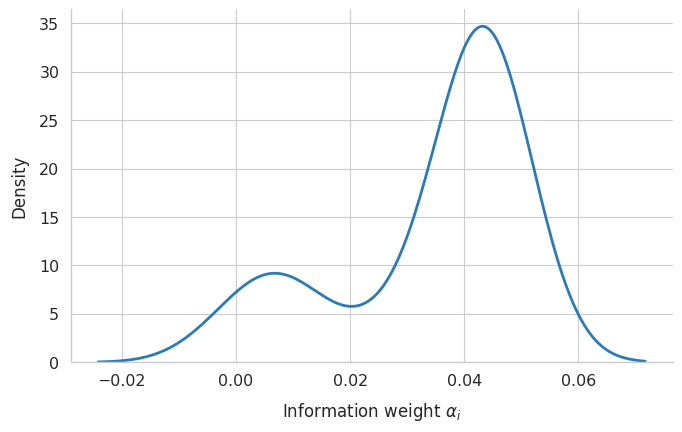

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="paper", font_scale=1.3)

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.kdeplot(
    df.information_weights,
    color="#2c7bb6",
    linewidth=2,
    ax=ax,
)

ax.set_xlabel(r"Information weight $\alpha_i$", fontsize=12, labelpad=8)
ax.set_ylabel(r"Density", fontsize=12, labelpad=8)

sns.despine()
plt.tight_layout()
plt.savefig("information_weights_dist.pdf", dpi=300, bbox_inches="tight")
plt.savefig("information_weights_dist.png", dpi=300, bbox_inches="tight")
plt.show()
 


In [38]:
df[df.information_weights.between(0.0, 0.02)].test_id.tolist()

['tests/test_align.py::TestAlign::test_apply_transform_ccddata',
 'tests/test_align.py::TestAlign::test_apply_transform_nddata',
 'tests/test_align.py::TestAlign::test_apply_transform_npma',
 'tests/test_align.py::TestAlign::test_find_sources',
 'tests/test_align.py::TestFewSources::test_find_transform_twosources',
 'tests/test_align.py::TestFewSources::test_register_twosources']

In [39]:
df[df.information_weights > 0.02].test_id.tolist()

['tests/test_align.py::TestAlign::test_consistent_invert',
 'tests/test_align.py::TestAlign::test_consistent_result',
 'tests/test_align.py::TestAlign::test_dtypes',
 'tests/test_align.py::TestAlign::test_fill_value',
 'tests/test_align.py::TestAlign::test_find_transform_givensources',
 'tests/test_align.py::TestAlign::test_register',
 'tests/test_align.py::TestAlign::test_register_ccddata',
 'tests/test_align.py::TestAlign::test_register_nddata',
 'tests/test_align.py::TestAlign::test_register_npma',
 'tests/test_align.py::TestAlign::test_unrepeated_sources',
 'tests/test_align.py::TestFewSources::test_find_transform_fivesources',
 'tests/test_align.py::TestFewSources::test_find_transform_foursources',
 'tests/test_align.py::TestFewSources::test_find_transform_sixsources',
 'tests/test_align.py::TestFewSources::test_find_transform_threesources',
 'tests/test_align.py::TestFewSources::test_register_fivesources',
 'tests/test_align.py::TestFewSources::test_register_foursources',
 'tests

In [42]:
df[["test_id", "coverage_alone"]].to_csv("cov.csv")


<Axes: xlabel='information_weights', ylabel='mutants_killed_without'>

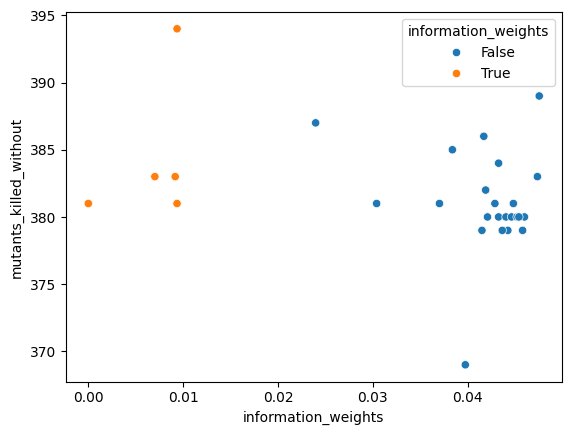

In [8]:
sns.scatterplot(data=df, x="information_weights", y="mutants_killed_without", hue=(df.information_weights < 0.01))

In [9]:
tests_number = proj.store.count_tests()


tests_number

29

In [10]:
ORDERING_METHOD = "mutants_killed_without"
ASCENDING = True
DROP_COLS = ["tests_ids", "created_at"]
columns = ['msr', 'tests_count',  
       'information_weights', 'mutants_killed', 'mutants_survived']
edf = proj.store.get_entropy_dataframe(ordering_method=ORDERING_METHOD, ascending=ASCENDING)
edf[columns]

/home/juan/misc/proyectos/yagua/src/yagua/dal/project_store.py:473: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.msr.replace(np.nan, None, inplace=True)


,msr,tests_count,information_weights,mutants_killed,mutants_survived
0,0.5594,1,0.021149,204,259
1,0.4471,2,0.026539,256,207
2,0.3823,3,0.029650,286,177
3,0.3737,4,0.030064,290,173
4,0.3477,5,0.031308,302,161
5,0.3499,6,0.031205,301,162
6,0.3456,7,0.031412,303,160
7,0.3456,8,0.031412,303,160
8,0.3456,9,0.031412,303,160
9,0.3283,10,0.032241,311,152


<Axes: xlabel='tests_count', ylabel='mutants_survived'>

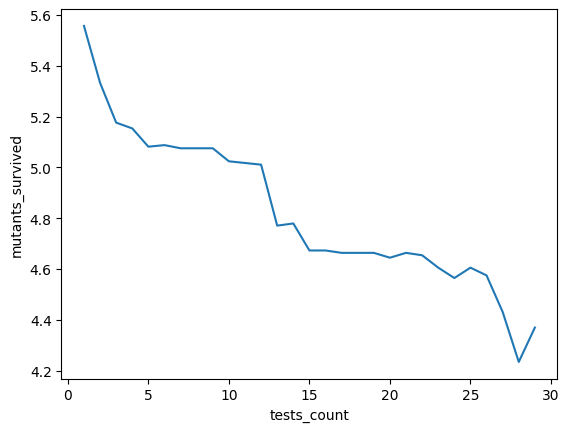

In [11]:
import numpy as np
sns.lineplot(data=edf, x="tests_count", y=np.log(edf.mutants_survived))

In [12]:
# sns.lineplot(data=edf, x="tests_count", y="msr")

In [13]:
import hashlib

def hashs(tests_ids):
    all_ids = "".join(sorted(tests_ids))
    md5 = hashlib.md5(all_ids.encode("utf8"))
    coso = md5.hexdigest()
    return f"get_survival_rate_for_tests_{coso}.sqlite"

edf["crayconf"] = edf.tests_ids.apply(hashs)

In [14]:
import sh
import sqlite3
folder = "/home/juan/misc/proyectos/yagua/src/_yagua_wd_astroalign_/yagua_cray"
test_total = proj.store.count_tests()

def get_crayconf_path(tests_count):
    coso = edf[edf.tests_count == tests_count]["crayconf"].tolist()[0]
    return f"{folder}/{coso}"

def outcomes(tests_count):
    if tests_count == test_total:
        path = f"{folder}/get_survival_rate.sqlite"
    else:
        path = get_crayconf_path(tests_count)
    with sqlite3.connect(path) as conn:
        df = pd.read_sql('select * from work_results', conn)
    the_outcomes = df.test_outcome.where(df.output != "timeout", "TIMEOUT")
    od = dict(sorted(the_outcomes.value_counts().to_dict().items()))
    return od.get("TIMEOUT", 0.) 

In [15]:
proj.store.mutants_number

463

In [16]:
import pandas as pd

rows = []
for _, row in edf.iterrows():
    
    tc = row.tests_count
    row = {
        "Tests": tc,
        "Mutants Survived": np.log(row.mutants_survived),
        "Timeout": outcomes(tc) / proj.store.mutants_number
    }
    rows.append(row)

toplot = pd.DataFrame(rows)
toplot;

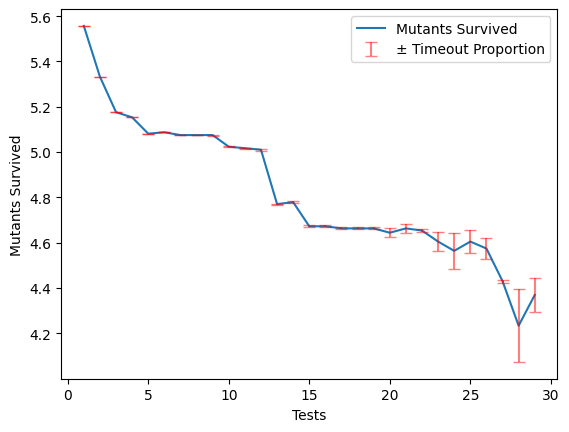

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt


df = toplot
sns.lineplot(
    data=df,
    x="Tests",
    y="Mutants Survived",
    label="Mutants Survived",
)

plt.errorbar(
    x=df["Tests"],
    y=df["Mutants Survived"],
    yerr=df["Timeout"],
    fmt='none',
    capsize=4,
    color='red',
    alpha=.5,
    label="± Timeout Proportion",
)
plt.legend()
plt.show()

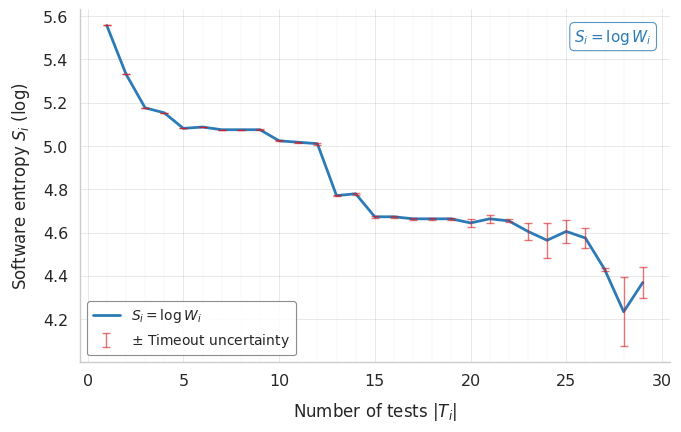

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

sns.set_theme(style="whitegrid", context="paper", font_scale=1.3)

fig, ax = plt.subplots(figsize=(7, 4.5))

df = toplot

# Línea principal
sns.lineplot(
    data=df,
    x="Tests",
    y="Mutants Survived",
    label=r"$S_i = \log W_i$",
    color="#2c7bb6",
    linewidth=2,
    ax=ax,
)

# Barras de error
ax.errorbar(
    x=df["Tests"],
    y=df["Mutants Survived"],
    yerr=df["Timeout"],
    fmt='none',
    capsize=3,
    capthick=1,
    elinewidth=1,
    color="#d7191c",
    alpha=0.6,
    label=r"$\pm$ Timeout uncertainty",
    zorder=3,
)

ax.set_xlabel(r"Number of tests $|T_i|$", fontsize=12, labelpad=8)
ax.set_ylabel(r"Software entropy $S_i$ (log)", fontsize=12, labelpad=8)

ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
ax.grid(True, which="major", linewidth=0.6, alpha=0.5)
ax.grid(True, which="minor", linewidth=0.3, alpha=0.3)

ax.legend(frameon=True, framealpha=0.9, edgecolor="gray", fontsize=10)

# Anotación de la fórmula en el plot
ax.annotate(
    r"$S_i = \log W_i$",
    xy=(0.97, 0.95),
    xycoords="axes fraction",
    ha="right", va="top",
    fontsize=11,
    color="#2c7bb6",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#2c7bb6", alpha=0.8),
)

sns.despine(left=False, bottom=False)
plt.tight_layout()
plt.savefig("entropy_curve.pdf", dpi=300, bbox_inches="tight")
plt.savefig("entropy_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
sns.lineplot?

Signature:
sns.lineplot(
    data=None,
    *,
    x=None,
    y=None,
    hue=None,
    size=None,
    style=None,
    units=None,
    weights=None,
    palette=None,
    hue_order=None,
    hue_norm=None,
    sizes=None,
    size_order=None,
    size_norm=None,
    dashes=True,
    markers=None,
    style_order=None,
    estimator='mean',
    errorbar=('ci', 95),
    n_boot=1000,
    seed=None,
    orient='x',
    sort=True,
    err_style='band',
    err_kws=None,
    legend='auto',
    ci='deprecated',
    ax=None,
    **kwargs,
)
Docstring:
Draw a line plot with possibility of several semantic groupings.

The relationship between `x` and `y` can be shown for different subsets
of the data using the `hue`, `size`, and `style` parameters. These
parameters control what visual semantics are used to identify the different
subsets. It is possible to show up to three dimensions independently by
using all three semantic types, but this style of plot can be hard to
interpret and is often ine